### corrPlaylist_1.ipynb

In [35]:
import os 
import numpy as np
import pandas as pd 
import random
from glob import glob # for grabbing files with wildcards
from itertools import combinations # for song 1/song 2 combinations

%autosave 300 

Autosaving every 300 seconds


In [36]:
# Define directories 
currPath = os.getcwd()
dataPath = os.path.abspath(os.path.join(currPath, os.pardir, 'data/playlist_subset'))

# Get the names of the playlist subsets
playlists = os.listdir(dataPath); playlists = [x for x in playlists if x.endswith('.gz')]; playlists.sort()

In [37]:
# Create a list of all songs

# Make the empty list
temp_song_list = []

#Add all the songs from each file
for p in playlists: 
    curr_playlist = pd.read_csv(os.path.join(dataPath, p), compression = 'gzip')
    temp_song_list.append(curr_playlist)


    print('Added songs from:', p)


#Initialize
temp_song_list = pd.concat(temp_song_list)


#Find pids from the sample
pid_list = temp_song_list['pid'].tolist()
pid_list = list(set(pid_list))


#Drop some data, then remove duplicated songs
temp_song_list = temp_song_list[['artist_name', 'track_name', 'track_uri', 'name']]
big_song_list = temp_song_list.drop_duplicates()


m = len(temp_song_list)
n = len(big_song_list)
print('I found', n, 'unique songs (out of', m, 'total songs).')


Added songs from: playlist_subset_1.csv.gz
Added songs from: playlist_subset_2.csv.gz
Added songs from: playlist_subset_3.csv.gz
Added songs from: playlist_subset_4.csv.gz
Added songs from: playlist_subset_4_test.csv.gz
Added songs from: playlist_subset_4_train.csv.gz
I found 1205732 unique songs (out of 1660420 total songs).


In [39]:
#Get a random pid
pid = 549015
#pid = random.choice(pid_list)
print('I chose the pid', pid)

#Reconstruct the playlist with this pid
sample_playlist = []
for p in playlists: 
    curr_playlist = pd.read_csv(os.path.join(dataPath, p), compression = 'gzip')
    sample_playlist.append(curr_playlist.loc[curr_playlist['pid'] == pid])

    print('Searched:', p)

#Initialize
sample_playlist = pd.concat(sample_playlist)

#Drop some data, then remove duplicated songs
#sample_playlist = sample_playlist[['artist_name', 'track_name', 'track_uri', 'name']]
#sample_playlist = sample_playlist.drop_duplicates()

print('This playlist has', len(sample_playlist), 'songs')




#Find all the playlists on which these tracks appear
sample_track_uris = sample_playlist['track_uri'].tolist()
pid_list = []
for p in playlists: 
    curr_playlist = pd.read_csv(os.path.join(dataPath, p), compression = 'gzip')
    temp_list = curr_playlist[curr_playlist['track_uri'].isin(sample_track_uris)] #Find all instances of the songs in the sample
    temp_list = temp_list['pid'].tolist()
    pid_list = pid_list + temp_list

    #print('searched:', p)

#Remove duplicates
pid_list = list(set(pid_list))

print('I found', len(pid_list), 'playlists containing at least one song from the sample')

#Find all songs that co-occur on a playlist with a song from the sample
co_occurring_songs = []
for p in playlists: 
    curr_playlist = pd.read_csv(os.path.join(dataPath, p), compression = 'gzip')
    temp_song_list = curr_playlist[curr_playlist['pid'].isin(pid_list)] #Find all co-occurring songs
    temp_song_list = temp_song_list[['artist_name', 'track_name', 'track_uri', 'name']]

    co_occurring_songs.append(temp_song_list)

    #print('searched:', p)


#Initialize
co_occurring_songs = pd.concat(co_occurring_songs)

#Drop duplicated songs
co_occurring_songs = co_occurring_songs.drop_duplicates()

#Remove the songs in the sample
co_occurring_songs = co_occurring_songs[co_occurring_songs['track_uri'].isin(sample_track_uris)]


print('I found', len(co_occurring_songs), 'other songs co-occurring with at least one song on the sample playlist')




I chose the pid 549015
Searched: playlist_subset_1.csv.gz
Searched: playlist_subset_2.csv.gz
Searched: playlist_subset_3.csv.gz
Searched: playlist_subset_4.csv.gz
Searched: playlist_subset_4_test.csv.gz
Searched: playlist_subset_4_train.csv.gz
This playlist has 25 songs
I found 857 playlists containing at least one song from the sample
I found 1229 other songs co-occurring with at least one song on the sample playlist


In [ ]:
#Pick n songs at random
#sample_playlist = big_song_list.sample(n=50)

#Get a list of the track uris
sample_track_uris = sample_playlist['track_uri'].tolist()


#Find all the playlists on which these tracks appear
pid_list = []
for p in playlists: 
    curr_playlist = pd.read_csv(os.path.join(dataPath, p), compression = 'gzip')
    temp_list = curr_playlist[curr_playlist['track_uri'].isin(sample_track_uris)] #Find all instances of the songs in the sample
    temp_list = temp_list['pid'].tolist()
    pid_list = pid_list + temp_list

    #print('searched:', p)

#Remove duplicates
pid_list = list(set(pid_list))

print('I found', len(pid_list), 'playlists containing at least one song from the sample')

#Find all songs that co-occur on a playlist with a song from the sample
co_occurring_songs = []
for p in playlists: 
    curr_playlist = pd.read_csv(os.path.join(dataPath, p), compression = 'gzip')
    temp_song_list = curr_playlist[curr_playlist['pid'].isin(pid_list)] #Find all songs co-occurring on a playlist
    temp_song_list = temp_song_list[['artist_name', 'track_name', 'track_uri', 'name']]

    co_occurring_songs.append(temp_song_list)

    #print('searched:', p)


#Initialize
co_occurring_songs = pd.concat(co_occurring_songs)

#Drop duplicated songs
co_occurring_songs = co_occurring_songs.drop_duplicates()

print('These playlists contained', len(co_occurring_songs), 'unique songs')

#Remove the songs in the sample
co_occurring_songs = co_occurring_songs[co_occurring_songs['track_uri'].isin(sample_track_uris)]
co_occurring_songs = co_occurring_songs.reindex()


I found 3299 playlists containing at least one song from the sample
These playlists contained 306433 unique songs
           artist_name                                         track_name  \
503           Ginuwine                                               Pony   
506            Shakira  Waka Waka (This Time for Africa) (The Official...   
507          Toploader                           Dancing in the Moonlight   
650         The Weeknd                                              Often   
773          Shop Boyz                             Party Like A Rock Star   
...                ...                                                ...   
328243  Pharoahe Monch                                         Simon Says   
328712       Shop Boyz                             Party Like A Rock Star   
329085      Luis Fonsi                                  Despacito - Remix   
329359         Beyoncé                                        Love On Top   
329363   WALK THE MOON                 

In [ ]:

#Generate a list of playlists containing one of the given tracks
co_occurring_songs = []

for p in playlists:
    curr_playlist = pd.read_csv(os.path.join(dataPath, p), compression = 'gzip')
    curr_playlist = curr_playlist[['artist_name', 'track_name', 'track_uri', 'pid', 'name']]

    songs_to_add = curr_playlist.loc[curr_playlist['pid'] == 549333]
    co_occurring_songs.append(songs_to_add)

print(co_occurring_songs)

[          artist_name                                         track_name  \
0       Nat King Cole                                     Deck The Halls   
1         Josh Groban  Little Drummer Boy - featuring guitarist Andy ...   
2        Idina Menzel   Baby It's Cold Outside (duet with Michael Bublé)   
3  Anita Kerr Singers                                   Jingle Bell Rock   
4           Trap City                   The Nutcracker Christmas Dubstep   

                              track_uri     pid             name  
0  spotify:track:0yOLhQVpava7cJhVDbCvSh  549333  Christmas music  
1  spotify:track:0Znrkkl2NYC2AEbgEbENSO  549333  Christmas music  
2  spotify:track:0Ie5uiv54KgCr7P4sYDTHl  549333  Christmas music  
3  spotify:track:4IdXngKo4g5exqZ0fQTecu  549333  Christmas music  
4  spotify:track:3HAYw27sjwSJNt9OuSJx55  549333  Christmas music  , Empty DataFrame
Columns: [artist_name, track_name, track_uri, pid, name]
Index: [], Empty DataFrame
Columns: [artist_name, track_name, trac

#### Get song frequency (across the entire playlist subset)

In [8]:
# Create our frequency master dataframe 
freq_master = []

# For every playlist file...
for p in playlists: 
    curr_playlist = pd.read_csv(os.path.join(dataPath, p), compression = 'gzip')
    curr_playlist = curr_playlist[['artist_name', 'track_name', 'track_uri', 'pid', 'name']]

    # Get the frequency for each song across playlists 
    curr_playlist_freq = curr_playlist.groupby(['artist_name', 'track_name', 'track_uri'])['pid'] \
                       .nunique() \
                       .reset_index(name='playlist_count_%i' % playlists.index(p))
    freq_master.append(curr_playlist_freq)
    

    print('Found song frequencies for:', p)


Found song frequencies for: playlist_subset_1.csv.gz
Found song frequencies for: playlist_subset_2.csv.gz
Found song frequencies for: playlist_subset_3.csv.gz
Found song frequencies for: playlist_subset_4.csv.gz


In [5]:
# Then, get the sum across columns 
freq_master = pd.concat(freq_master) # initialize df
freq_master.groupby('track_uri', as_index=False).sum(numeric_only=True) # group by track identifier 

# Organize frequencies acccording to each song in one row (instead of multiple rows per song)
merged_freq = (
    freq_master
    .fillna(0)
    .groupby('track_uri', as_index=False)[['playlist_count_0', 'playlist_count_1', 'playlist_count_2', 'playlist_count_3']]  # your specific columns
    .sum()
)

# Combine our song metadata with our frequencies
metadata = freq_master.groupby('track_uri', as_index=False).first()
metadata = metadata.drop(columns=['playlist_count_0', 'playlist_count_1', 'playlist_count_2', 'playlist_count_3'])
merged_freq = pd.merge(merged_freq, metadata, on='track_uri')

# Then, get the summed frequency across playlist files
merged_freq['total'] = merged_freq[['playlist_count_0', 'playlist_count_1', 'playlist_count_2', 'playlist_count_3']].sum(axis=1)

# Sort our dataframe by the most frequent songs
merged_freq = merged_freq.sort_values(by='total', ascending = False) # organize frequencies by most to least
merged_freq.reset_index(drop=True, inplace=True)

# Save our merged frequency dataframe in our dataframe
merged_freq.to_csv(os.path.join(dataPath, 'freq/song_frequency.csv.gz'), index=False, compression = 'gzip')

#### Work with subset of data (300 songs)

In [18]:
# Get the subset of data (300 most frequency songs)
freq_subset = merged_freq[:300]

# Create the dummy correlation matrix to fill in later
corr_matrix = np.zeros((len(freq_subset), len(freq_subset)), dtype=int)

In [19]:
# First, assign each song with an idx for our future dataframe (via making a dictionary)
track_idx = {song: idx for idx, song in enumerate(freq_subset['track_uri'].values)}

In [20]:
# For each playlist, check songs accordingly... 
for p in playlists: 
    playlist_df = pd.read_csv(os.path.join(dataPath, p), compression = 'gzip')
    playlist_df = playlist_df[['artist_name', 'track_name', 'track_uri', 'pid', 'name']]

    # For every playlist... (chosen by their playlist id)
    for pid in np.unique(playlist_df['pid'].values):
        curr_playlist = playlist_df[playlist_df['pid'] == pid]

        # See whether song from subset are present in current playlist 
        tracks_in_playlist = [x for x in curr_playlist['track_uri'] if x in track_idx] 

        # Then, apply numbers to co-present songs 
        for song1, song2 in combinations(set(tracks_in_playlist), 2):  # set() avoids duplicates within a playlist
            idx1 = track_idx[song1]; idx2 = track_idx[song2]
            corr_matrix[idx1, idx2] += 1; corr_matrix[idx2, idx1] += 1


In [21]:
# Get song names for each track
song_names = []
for x, y in track_idx.items(): 
    # For each track, get the song title 
    song_names.append(freq_subset[freq_subset['track_uri'] == x]['track_name'].values[0])

# Then, apply the song names to the index and columns of our correlation matrix 
corr_matrix_df = pd.DataFrame(corr_matrix, index=song_names, columns=song_names)

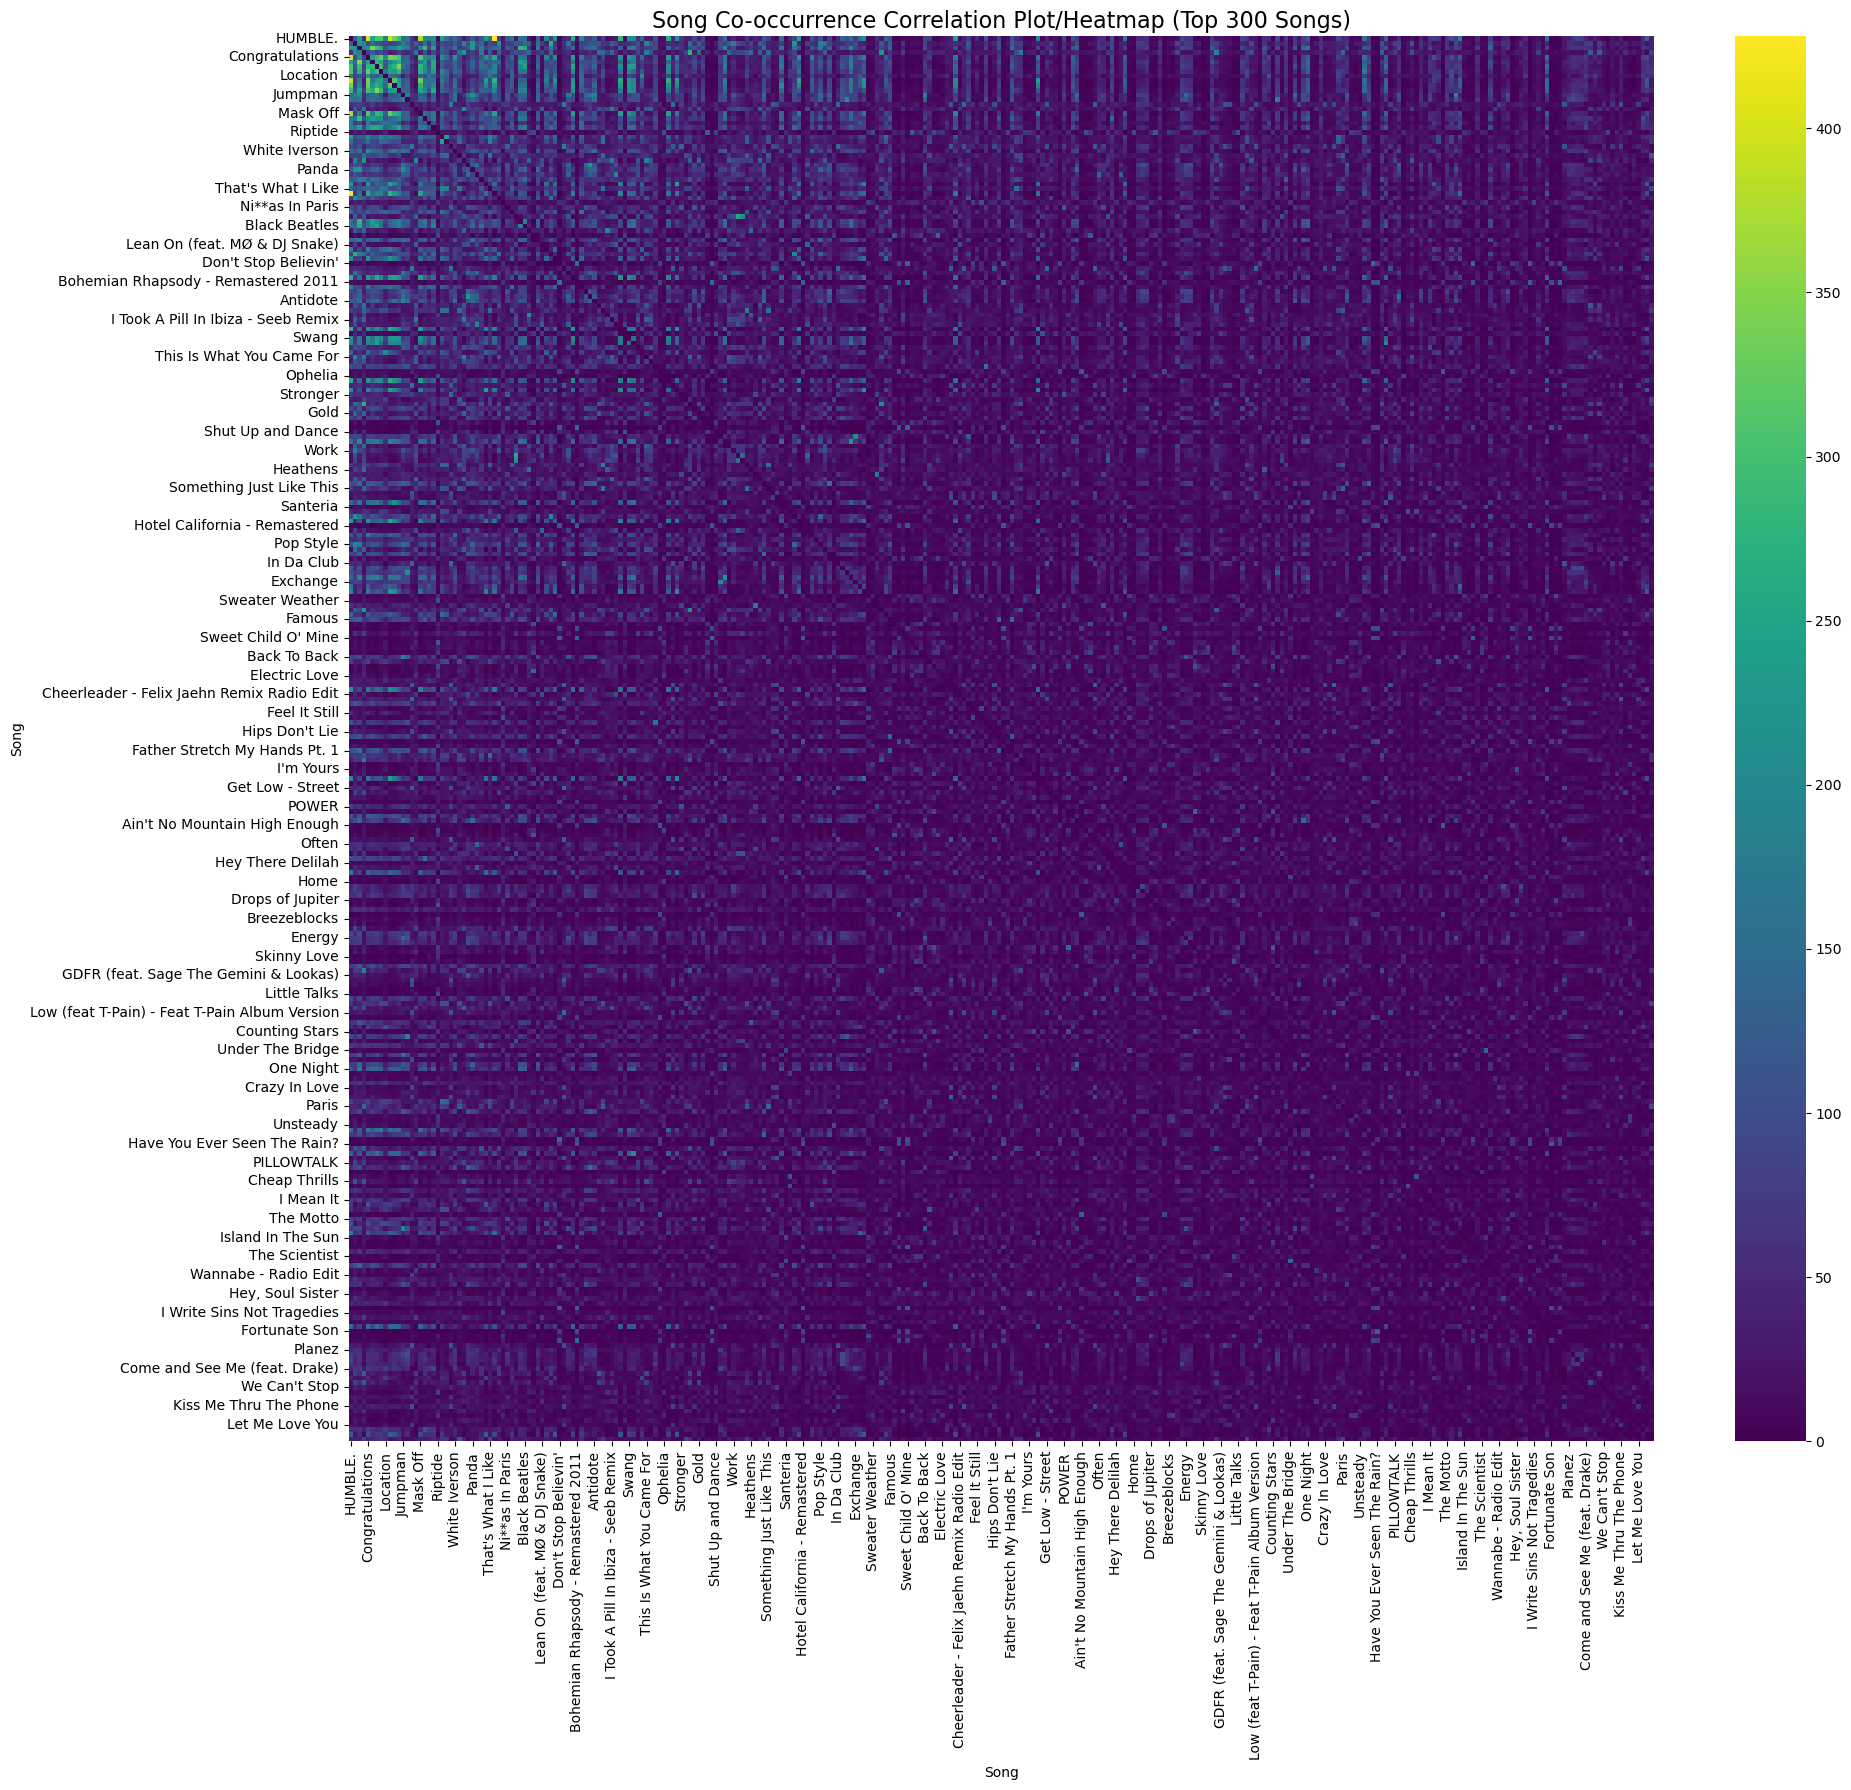

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 18))  # Adjust size as needed
sns.heatmap(corr_matrix_df, cmap="viridis")  # Other options: "Blues", "magma", "coolwarm"
plt.title("Song Co-occurrence Correlation Plot/Heatmap (Top 300 Songs)", fontsize=16)
plt.xlabel("Song")
plt.ylabel("Song")
plt.tight_layout()
plt.show()

#### Run a PCA

In [298]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2) # determine how many dimensions
song_transformed = pca.fit_transform(corr_matrix_df.values) # fitting and transforming at the same time

In [299]:
# Also, get the names for the top 15 most frequent songs (so we can label later)
top15_songs = freq_subset[:15]['track_name'].values

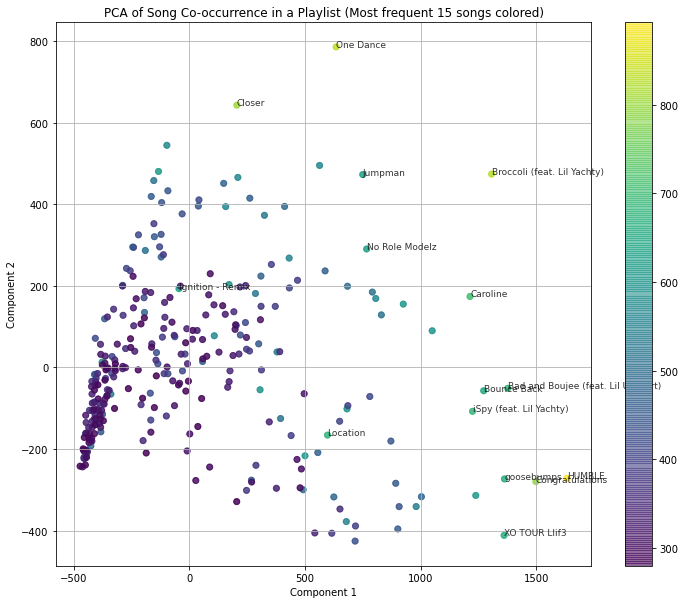

In [300]:
# Create the pca dataframe
pca_df = pd.DataFrame(song_transformed, columns=['PC1', 'PC2'], index=corr_matrix_df.index) # place pca transformed vals in dataframe

# Also, include the playlist frequencies in our dataset (for coloring later)
pca_df['playlist_freq'] = freq_subset['total'].values

# Plot
plt.figure(figsize=(12, 10))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['playlist_freq'], alpha=0.6, cmap='viridis')
plt.colorbar(plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['playlist_freq'], alpha=0.6, cmap='viridis')) # include colorbar

# Find the location of the top 15 songs + label them
for song in top15_songs:
    x = pca_df.loc[song, 'PC1']
    y = pca_df.loc[song, 'PC2']
    plt.text(x, y, song, fontsize=9, alpha=0.8)

plt.title("PCA of Song Co-occurrence in a Playlist (Most frequent 15 songs colored)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()
